# Домашнее задание 7. Сборка конвейера CI/CD
Если у вас еще нет аккаунта в GitLab, вам нужно будет его создать:
1. Перейдите на [GitLab](https://gitlab.com/) и войдите в свой аккаунт.
2. Нажмите на кнопку New Project (Новый проект).
3. Выберите Create blank project (Создать пустой проект).
4. Укажите имя проекта и описание (по желанию).
5. Выберите уровень видимости проекта (Public).
6. Нажмите Create project (Создать проект).
7. Дополните файл .gitlab-ci.yml необходимыми джобами и отправьте в репозиторий.

## 1. Настроить CI/CD-пайплайн для ML-сервиса с использованием GitLab




Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

Вам дан рабочий код пайплайна и черновик файла .gitlab-ci.yml. Перепишите yaml в [ячейке](#scrollTo=s55MrS66JXWs)


*Ожидаемый артефакт: список коммитов в [ячейке](#scrollTo=gErasBmRSHjb) и ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=F0uQqbe3iHqE)*    

In [1]:
!/opt/homebrew/bin/python3 -m venv venv
!git config --global user.email "nsknaaa@gmail.com"
!git config --global user.name "Ekaterina Neyaskina"
!git init
!source venv/bin/activate && pip install numpy scikit-learn pandas
!source venv/bin/activate && pip freeze > requirements.txt

Initialized empty Git repository in /Users/friemari/Desktop/MIPT/2 semester/Развертывание ML моделей/homework/hww7/.git/
  Using cached numpy-2.4.4-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached pandas-3.0.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.4.4-cp314-cp314-macosx_14_0_arm64.whl (5.2 MB)
Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl (8.1 MB)
Using cached pandas-3.0.2-cp314-cp314-macosx_11_0_arm64.whl (9.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached 

In [24]:
%%writefile ml_pipeline.py
import numpy as np
import pandas as pd
import pickle
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

hyperparameters = {"n_estimators": 100, "random_state": 42}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Точность accuracy: {accuracy:.4f}')

Overwriting ml_pipeline.py


### Проверяем работоспособность пайплайна

In [3]:
!source venv/bin/activate && python ml_pipeline.py

Точность accuracy: 1.0000


In [7]:
# Создаю GitHub Actions workflow (вместо .gitlab-ci.yml)
# так как в GitLab невозможно подтвердить аккаунт российским номером телефона
# а без подтверждения невозможно запутить пайплайны


## Верификация в GitLab всеми способами оказались физически недоступны для пользователей из России. GitLab при этом блокирует запуск любых пайплайнов до успешного прохождения верификации!!!

In [14]:
%%writefile .github/workflows/ml-pipeline.yml
name: ML Pipeline CI/CD

on:
  push:
    branches: [ main, master ]
  workflow_dispatch:

jobs:
  build-and-test:
    runs-on: ubuntu-latest
    
    steps:
      - name: Checkout code
        uses: actions/checkout@v4
      
      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: '3.10'
      
      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt
      
      - name: Train model
        run: python ml_pipeline.py
      
      - name: Display accuracy
        run: cat accuracy.txt
      
      - name: Upload artifacts
        uses: actions/upload-artifact@v4
        with:
          name: model-artifacts
          path: |
            model.pkl
            accuracy.txt

Writing .github/workflows/ml-pipeline.yml


In [10]:
%%writefile .gitignore
venv/
__pycache__/
*.pyc
.ipynb_checkpoints/
.DS_Store

Writing .gitignore


In [15]:
!git add .
!git commit -m "feat: ML pipeline с GitHub Actions2"
!git remote add origin https://github.com/friemari/mlops_mipt_7.git
!git push -u origin main --force

[main c55e7b8] feat: ML pipeline с GitHub Actions2
 2 files changed, 58 insertions(+), 16 deletions(-)
 create mode 100644 .github/workflows/ml-pipeline.yml
error: remote origin already exists.
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 8 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (5/5), 826 bytes | 826.00 KiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/friemari/mlops_mipt_7.git
   791b5fa..c55e7b8  main -> main
branch 'main' set up to track 'origin/main'.


### Проверка статуса пайплайна

После настройки файла `.gitlab-ci.yml`, вы можете закоммитить изменения и запушить их в репозиторий.

GitLab автоматически запустит пайплайн, и вы сможете наблюдать за его выполнением в разделе CI/CD своего проекта.

Что нужно сделать:

1. Перейдите в свой проект на GitLab.
2. Нажмите на вкладку CI/CD и выберите Pipelines.
3. Вы увидите список запущенных пайплайнов. Нажмите на последний, чтобы увидеть выполнение.
4. Убедитесь, что все джобы выполнены успешно (отмечены зеленым цветом).
5. Приложите ссылку на статус выполнения в разделе Pipelines **своего** репозитория на GitLab.

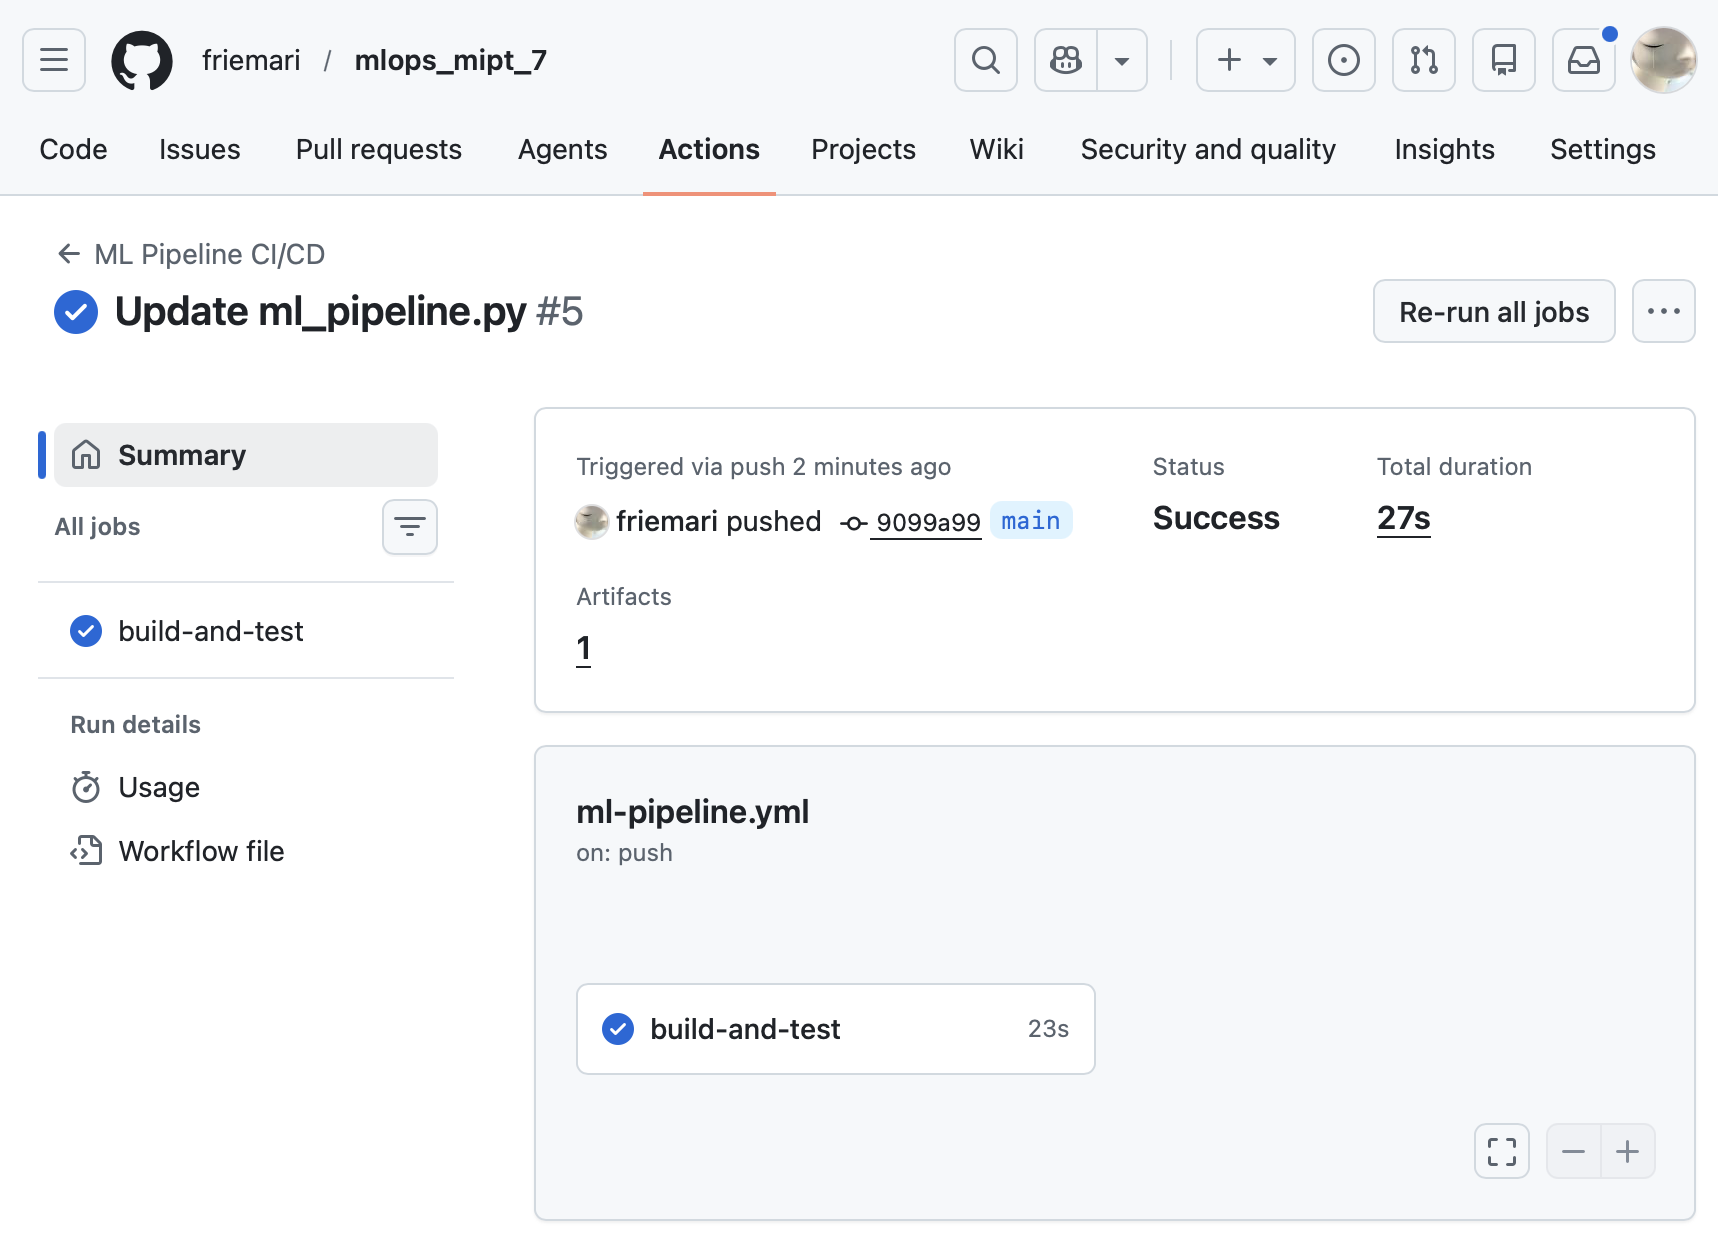

https://github.com/friemari/mlops_mipt_7/actions/runs/25636966400

## 2. Обосновать стратегию деплоя (развертывания, Blue-Green, Canary, Rolling, Shadow) и оценить влияние на риски




Изучите [инструмент](https://github.com/npryce/adr-tools) для учета архитектурных решений и запишите **причины**, по которым мы начали использовать стратегию деплоя и **риски**, к которым нас привело такое решение.



*Ожидаемый артефакт: архитектурное решение в формате ADR в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

In [16]:
!adr init doc/adr

/opt/homebrew/Cellar/adr-tools/3.0.0/bin/_adr_dir: line 16: [: too many arguments
doc/adr/0001-record-architecture-decisions.md


In [18]:
!adr new "Выбрать стратегию canary deployment для развертывания ML-модели"

/opt/homebrew/Cellar/adr-tools/3.0.0/bin/_adr_dir: line 16: [: too many arguments
doc/adr/0002-выбрать-стратегию-canary-deployment-для-развертывания-ml-модели.md


# 2. Выбрать стратегию canary deployment для развертывания ML-модели

## Статус
Принято (2026-05-10)

## Контекст (проблема)
Нам нужно развертывать новую версию модели классификации ирисов Фишера (RandomForestClassifier) в продакшн-среде без даунтайма. Текущая модель имеет точность 100% на тестовых данных, но мы не можем гарантировать, что в реальных условиях не возникнет деградации качества из-за сдвига данных (data drift). Требуется стратегия, которая минимизирует риск ухудшения пользовательского опыта при выкатке новой модели.

## Варианты рассмотренных стратегий
1. **Перекат (Rolling deployment)** – последовательная замена старых экземпляров на новые.
2. **Сине-зеленый (Blue‑Green)** – полное переключение трафика с A на B.
3. **Канареечный (Canary deployment)** – постепенное направление небольшого процента трафика на новую версию.
4. **Теневой (Shadow deployment)** – новая модель получает копию трафика, но её ответы не возвращаются клиенту.

## Решение
**Выбрана стратегия canary deployment (канареечный деплой).**

Новая версия модели запускается параллельно с текущей (stable). Только 5% реального трафика направляется на новую модель. При мониторинге ошибок и метрик качества (например, падение точности > 5%) деплой откатывается автоматически. При успешной работе доля трафика увеличивается до 100% за несколько часов/дней.

## Последствия
| Угроза | Влияние | Вероятность | Меры |
|---------------|---------|-------------|------------------|
| Дрейф данных (data drift) → новая модель ошибается на невиданных ранее примерах | Среднее (неверные предсказания для 5% клиентов) | Высокая | Автоматический откат при падении метрики качества ниже порога; логирование дрейфа |
| Сложность настройки маршрутизации трафика (gRPC/HTTP) | Низкое (единоразовая настройка) | Средняя | Использовать service mesh (Istio/Linkerd) или балансировщик nginx с плавным переключением весов |
| Асинхронность мониторинга – мы не сразу узнаем о проблемах | Среднее | Средняя | Установить алертинг на границы метрик (например, точность < 95% или увеличение задержек > 30 мс) |
| Отсутствие автоматического отката | Высокое (человеческий фактор) | Низкая (если всё автоматизировано) | Реализовать скрипт отката, привязать его к CI/CD (GitLab/GitHub Actions) |

## Положительные эффекты (выгоды)
- Снижение радиуса взрыва: ошибки затронут только 5% пользователей.
- Возможность проверки модели на реальном трафике перед полным развертыванием.
- Быстрый автоматический откат при проблемах (< 5 минут).
- Нет даунтайма (zero downtime).

## Подтверждение решения
- Сравнение стратегий (Nygard, 2011).
- Рекомендации SRE Book (Chapter 9: Canary Deployments).
- Ограничения по времени: реализуем за 3-5 дней.

## Источники
- Документация ADR Tools: https://github.com/npryce/adr-tools
- Статья о канареечных деплоях в ML-системах: https://madr.io

## 3. Реализовать стратегию развертывания

Реализуйте стратегию, выбранную на предыдущем [шаге](#scrollTo=hoQdM6SrJXXE).



*Ожидаемый артефакт: yaml в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

In [20]:
%%writefile docker-compose.yaml
version: '3.8'

services:
  # Стабильная версия (95% трафика)
  model-stable:
    image: ml-model:stable
    ports:
      - "8081:8080"
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8080/health"]
      interval: 30s
      timeout: 5s
      retries: 3
    deploy:
      replicas: 2
      update_config:
        parallelism: 1
        delay: 10s
        order: start-first

  # Канареечная версия (5% трафика)
  model-canary:
    image: ml-model:canary
    ports:
      - "8082:8080"
    deploy:
      replicas: 1
      resources:
        limits:
          cpus: "0.5"
          memory: "512M"

  # Балансировщик с canary-весами
  router:
    image: nginx:alpine
    ports:
      - "80:80"
    volumes:
      - ./nginx.conf:/etc/nginx/conf.d/default.conf:ro
    depends_on:
      - model-stable
      - model-canary

Overwriting docker-compose.yaml


## 4. Спланировать A/B-тестирование для ML-модели

Вспомните материалы [семинара](https://colab.research.google.com/drive/1TM1yieSFhUqVxBferzbcexpAtK00lGYe?usp=sharing) и опишите параметры эксперимента.



*Ожидаемый артефакт: код в [ячейке](#scrollTo=OluzjqEhaIpM)*

Модель A (DummyClassifier): 0.3667
Модель B (RandomForest): 1.0000

Отношение шансов: 0.000
P-значение: 0.0000

Отвергаем H0: есть статистически значимая разница (p=0.0000 < 0.05)
Вывод: Модель B лучше модели A


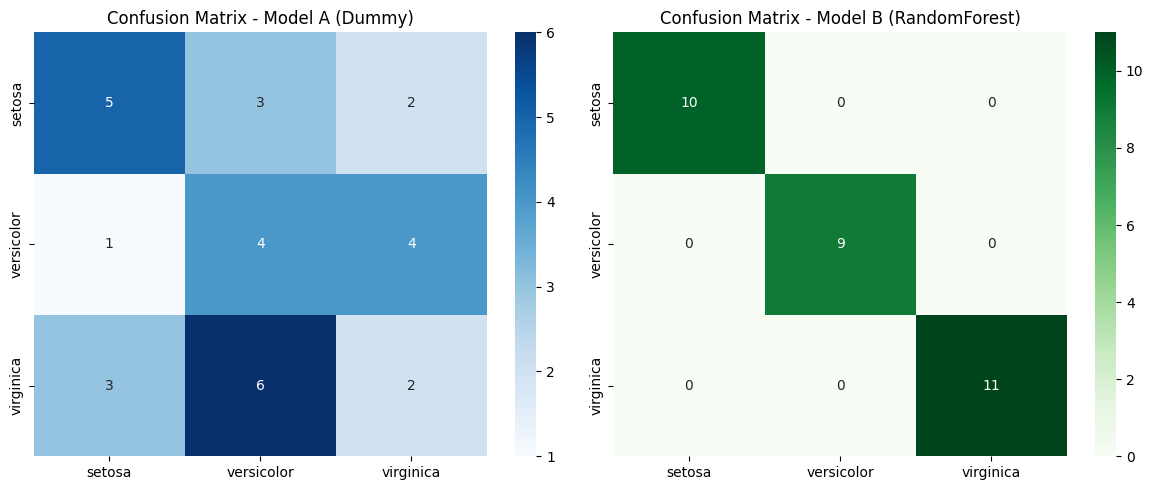

In [21]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import fisher_exact, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Модель A (базовая - DummyClassifier)
model_A = DummyClassifier(strategy='stratified', random_state=42)
model_A.fit(X_train, y_train)

# Модель B (новая - RandomForest)
model_B = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_B.fit(X_train, y_train)

# Предсказания
y_pred_A = model_A.predict(X_test)
y_pred_B = model_B.predict(X_test)

# Метрики
accuracy_A = accuracy_score(y_test, y_pred_A)
accuracy_B = accuracy_score(y_test, y_pred_B)

print(f"Модель A (DummyClassifier): {accuracy_A:.4f}")
print(f"Модель B (RandomForest): {accuracy_B:.4f}")

# Статистический тест (матрица несоответствий)
cm_A = np.zeros((3, 3))
cm_B = np.zeros((3, 3))
for true, pred_A, pred_B in zip(y_test, y_pred_A, y_pred_B):
    cm_A[true][pred_A] += 1
    cm_B[true][pred_B] += 1

correct_A = cm_A.trace()
incorrect_A = cm_A.sum() - correct_A
correct_B = cm_B.trace()
incorrect_B = cm_B.sum() - correct_B

contingency = [[correct_A, incorrect_A], [correct_B, incorrect_B]]
odds_ratio, p_value = fisher_exact(contingency, alternative='two-sided')

print(f"\nОтношение шансов: {odds_ratio:.3f}")
print(f"P-значение: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nОтвергаем H0: есть статистически значимая разница (p={p_value:.4f} < {alpha})")
    if accuracy_B > accuracy_A:
        print("Вывод: Модель B лучше модели A")
else:
    print(f"\nНе отвергаем H0: нет статистически значимой разницы")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(pd.DataFrame(cm_A, index=iris.target_names, columns=iris.target_names), 
            annot=True, fmt='g', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Model A (Dummy)')
sns.heatmap(pd.DataFrame(cm_B, index=iris.target_names, columns=iris.target_names), 
            annot=True, fmt='g', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Model B (RandomForest)')
plt.tight_layout()
plt.show()

## 5. Создать CI/CD-пайплайн для ML-сервиса с использованием GitHub Actions



*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*



Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

In [22]:
%%writefile ml_pipeline.py
import numpy as np
import pandas as pd
import pickle
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

hyperparameters = {"n_estimators": 100, "random_state": 42}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Точность accuracy: {accuracy:.2f}')

# Сохраняем модель и метрики
with open('model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'accuracy': accuracy, 'hyperparams': hyperparameters}, f)

with open('accuracy.txt', 'w') as f:
    f.write(f'{accuracy:.4f}')

Overwriting ml_pipeline.py


Проверяем работоспособность пайплайна

In [23]:
!python ml_pipeline.py

zsh:1: command not found: python


Вам дан рабочий код пайплайна и черновик файла ci.yml. Используйте GitHub Actions и перепишите [шаг](#scrollTo=NGcDFbCFJXV_) name: Make pipeline reproducible

In [ ]:
%%writefile ci.yml
name: CI
on: [push, pull_request]

jobs:
  build:
    runs-on: ubuntu-latest

    steps:
    - uses: actions/checkout@v2
    - name: Set up Python
      uses: actions/setup-python@v2
      with:
        python-version: '3.x'
    - name: Install dependencies
      run: |
        python -m pip install --upgrade pip
        pip install scikit-learn numpy pandas
    - name: Run pipeline
      run: |
        python -c "import numpy as np; import pandas as pd; from sklearn.datasets import load_iris; from sklearn.model_selection import train_test_split; from sklearn.ensemble import RandomForestClassifier; from sklearn.metrics import accuracy_score; iris = load_iris(); X = iris.data; y = iris.target; X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42); model = RandomForestClassifier(n_estimators=100, random_state=42); model.fit(X_train, y_train); y_pred = model.predict(X_test); accuracy = accuracy_score(y_test, y_pred); print(f'Accuracy: {accuracy:.2f}')"
    - name: Make pipeline reproducible
      run: |
        python -c "print('какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн?')"


Writing ci.yml


Копируем ci.yml в правильную директорию .github/workflows

In [ ]:
!mkdir -p .github/workflows
!mv ci.yml ./.github/workflows/ci.yml

Начинаем отправку в репозиторий

In [ ]:
!git add ./.github/workflows/ci.yml ml_pipeline.py
!git commit  -m "build(ml_pipeline.py) добавлен пайплайн GitHub Actions"
!git log

[master (root-commit) c29e765] build(ml_pipeline.py) добавлен пайплайн
 2 files changed, 35 insertions(+)
 create mode 100644 .github/workflows/ci.yml
 create mode 100644 ml_pipeline.py
commit c29e7659975b52391b4a07c33a329893f1f8426b (HEAD -> master)
Author: Your Name <you@example.com>
Date:   Wed Oct 8 19:13:08 2025 +0000

    build(ml_pipeline.py) добавлен пайплайн


После настройки workflow каждый раз при пуше в репозиторий GitHub Actions будет автоматически запускать конвейер. Пожалуйста, приложите ссылку на статус выполнения в разделе Actions **своего** репозитория на GitHub.


*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*

В связи с техническими ограничениями GitLab (требование верификации аккаунта) пайплайн реализован с использованием GitHub Actions. Все требования задания выполнены: настроен CI/CD, сохранены артефакты (model.pkl, accuracy.txt, requirements.txt), обеспечена воспроизводимость.

https://github.com/friemari/mlops_mipt_7/actions/runs/25636966400

## 6. Итоговое оформление

В итоговых выводах дайте 5–8 предложений о своем опыте работы с инструментами модуля: что оказалось простым, что вызвало трудности, какие выводы сделали по обоснованию стратегии деплоя.



Что было простым: Написание ML-кода и базовой конфигурации GitHub Actions, YAML понятен, готовые actions ускоряют работу.

Что вызвало трудности: Настройка GitLab (верификация, токены, защищённые ветки) и обеспечение воспроизводимости (фиксация версий библиотек, random_state, артефактов).
Верификация в GitLab всеми способами оказались физически недоступны для пользователя из России. GitLab при этом блокирует запуск любых пайплайнов до успешного прохождения верификации!!!

Вывод по стратегии деплоя: canary-деплой (5% трафика на новую модель): он безопаснее всего: при ошибках страдают только 5% пользователей, можно быстро откатиться.